In [1]:
# #to fetch ic5o with header  run the bewlow  command in terminal 
# #head -n 1 ABL1_P00519_values.csv > ABL1_P00519_IC50_only.csv
# #grep "IC50" ABL1_P00519_values.csv >> ABL1_P00519_IC50_only.csv


import os
os.chdir('/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/TTBK1')

import pandas as pd

# # Load both datasets
# df1 = pd.read_csv("ABL1_CHEMBL1862_IC50_chembl_Wsmile.csv")
# df2 = pd.read_csv("ABL1_P00519_IC50_only.csv")


# df2 = df2[["SMILES", "Affinity Value"]]
# df2.columns = ["smiles", "standard_value"]  # rename for consistency

# common_smiles = set(df1["smiles"]) & set(df2["smiles"])

# # Filter rows with common SMILES
# df1_common = df1[df1["smiles"].isin(common_smiles)][["smiles", "standard_value"]].rename(columns={"standard_value": "IC50_df1"})
# df2_common = df2[df2["smiles"].isin(common_smiles)][["smiles", "standard_value"]].rename(columns={"standard_value": "IC50_df2"})

# # Merge on SMILES
# merged = pd.merge(df1_common, df2_common, on="smiles")

# # print(merged)  # Show first 10 entries

# print(f"Number of common SMILES: {len(common_smiles)}")
# # print(list(common_smiles)[:10])  # Print first 10 for preview

# # # Combine the two datasets
# combined_df = pd.concat([df1, df2], ignore_index=True)
# combined_df


# # # Drop entries with missing SMILES or IC50
# combined_df = combined_df.dropna(subset=["smiles", "standard_value"])
# combined_df
# # # Convert IC50 values to numeric
# combined_df["standard_value"] = pd.to_numeric(combined_df["standard_value"], errors="coerce")
# # combined_df
# # # Drop any rows with NaNs in standard_value after conversion
# combined_df = combined_df.dropna(subset=["standard_value"])
# combined_df

# # # Keep only the entry with the lowest IC50 for each SMILES
# min_ic50_df = combined_df.loc[combined_df.groupby("smiles")["standard_value"].idxmin()]
# min_ic50_df
# # # Select only relevant columns
# final_df = min_ic50_df[["smiles", "standard_value"]].reset_index(drop=True)

# # # Save to a new CSV file
# final_df.to_csv("dedeuplicated_combined_ic50.csv", index=False)



In [3]:
final_df= pd.read_csv("dedeuplicated_combined_ic50.csv")
##check for duplication
# Ensure SMILES column is treated as string
final_df["smiles"] = final_df["smiles"].astype(str)

# Check for duplicates in the 'smiles' column
duplicates = final_df[final_df.duplicated("smiles", keep=False)]  # keep=False shows *all* duplicates

# Print number and preview of duplicates
print(f"Total duplicate SMILES entries: {len(duplicates)}")
print(duplicates.head())



Total duplicate SMILES entries: 0
Empty DataFrame
Columns: [smiles, standard_value, is_valid, label]
Index: []


In [4]:
from rdkit import Chem
import pandas as pd


# Check for invalid SMILES
def check_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None
final_df['is_valid'] = final_df['smiles'].apply(check_smiles)

# Report
invalid_smiles = final_df[~final_df['is_valid']]
print(f"Total SMILES: {len(final_df)}")
print(f"Invalid SMILES: {len(invalid_smiles)}")

if not invalid_smiles.empty:
    print("List of invalid SMILES:")
    print(invalid_smiles[['smiles']])
else:
    print("✅ All SMILES are valid.")


# remove the invalid using
final_df = final_df[final_df['is_valid']]
# final_df.to_csv("dedeuplicated_combined_ic50.csv", index=False)

Total SMILES: 124
Invalid SMILES: 0
✅ All SMILES are valid.


In [5]:
#classification actives/inactives

# 2) Convert IC50 column to numeric (in case there were strings)
final_df['standard_value'] = pd.to_numeric(final_df['standard_value'], errors='coerce')

# 3) Add classification column
final_df['label'] = (final_df['standard_value'] < 1000).astype(int)
# 1 = Active, 0 = Inactive


# 4) Quick sanity check
print(final_df[['standard_value', 'label']].head())

# 5) (Optional) Save back out
final_df.to_csv("dedeuplicated_combined_ic50.csv", index=False)


   standard_value  label
0           750.0      1
1           390.0      1
2           750.0      1
3          4900.0      0
4          4700.0      0


In [6]:
# Count how many of each
counts = final_df['label'].value_counts().sort_index()
print("Inactives (0):", counts.get(0, 0))
print("Actives   (1):", counts.get(1, 0))
print(len(final_df))

Inactives (0): 49
Actives   (1): 75
124


In [ ]:
# # #SMILE AUGMENTATION FOR TTBK ( not needed anymore)
# from rdkit import Chem
# from rdkit.Chem import MolToSmiles
# import pandas as pd

# def random_smiles(smiles, n=5):
#     mol = Chem.MolFromSmiles(smiles)
#     return [MolToSmiles(mol, doRandom=True) for _ in range(n)]

# # Load your small-data TTBK DataFrame with columns: smiles, label
# ttbk_df = pd.read_csv("dedeuplicated_combined_ic50.csv")

# augmented_rows = []
# for _, row in ttbk_df.iterrows():
#     smi, lbl = row['smiles'], row['label']
#     for rnd_smi in random_smiles(smi, n=5):
#         augmented_rows.append({'smiles': rnd_smi, 'label': lbl})

# aug_df = pd.DataFrame(augmented_rows)
# # Combine with the original
# ttbk_augmented = pd.concat([ttbk_df, aug_df], ignore_index=True)
# ttbk_augmented.to_csv("trial.csv")
# ttbk_augmented



,smiles,standard_value,is_valid,label
0,Brc1ccc(Oc2ccc(Nc3ncnc4[nH]ccc34)cc2)cc1,750.0,True,0
1,C(Cn1cc(COc2ccc(Nc3ncnc4[nH]ccc34)cc2)nn1)c1cc...,390.0,True,0
2,C(Oc1ccc(Nc2ncnc3[nH]ccc23)cc1)c1ccccc1,750.0,True,0
3,C1CN(CCO1)c1ccc(Nc2ncnc3[nH]ccc23)cc1,4900.0,True,0
4,C1CN(CCO1)c1cccc(Nc2ncnc3[nH]ccc23)c1,4700.0,True,0
...,...,...,...,...
739,c1(ccc(cc1)N1CCOCC1)Nc1ncnc2c1cc[nH]2,NaN,NaN,0
740,n1c(Nc2ccc(N3CCOCC3)cc2)c2c([nH]cc2)nc1,NaN,NaN,0
741,c1(N2CCOCC2)ccc(Nc2c3c([nH]cc3)ncn2)cc1,NaN,NaN,0
742,c12c(cc[nH]2)c(Nc2ccc(N3CCOCC3)cc2)ncn1,NaN,NaN,0


In [14]:
# Count how many of each
counts = aug_df['label'].value_counts().sort_index()
print("Inactives (0):", counts.get(0, 0))
print("Actives   (1):", counts.get(1, 0))
print(len(aug_df))

Inactives (0): 455
Actives   (1): 165
620


Running pipeline...
Loaded 744 clean entries; labels: [0, 1]
SMILES valid on sample: 100.0%
FP test: 5/5 successful
Class distribution before SMOTE: {0: 437, 1: 158}
Applying SMOTE...
Train size: 595 → 874 after SMOTE
Pipeline completed.
                                              smiles  label
0           Brc1ccc(Oc2ccc(Nc3ncnc4[nH]ccc34)cc2)cc1      0
1  C(Cn1cc(COc2ccc(Nc3ncnc4[nH]ccc34)cc2)nn1)c1cc...      0
2            C(Oc1ccc(Nc2ncnc3[nH]ccc23)cc1)c1ccccc1      0
3              C1CN(CCO1)c1ccc(Nc2ncnc3[nH]ccc23)cc1      0
4              C1CN(CCO1)c1cccc(Nc2ncnc3[nH]ccc23)c1      0


In [ ]:
import numpy as np
import pandas as pd
import joblib
import json
from collections import defaultdict
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (f1_score, roc_auc_score, average_precision_score)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

# ──────────────────────────────────────────────────────────────────────────────
# Utility Functions
# ──────────────────────────────────────────────────────────────────────────────
def generate_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol) if mol else None

def smiles_to_fp(smiles_list, radius=2, nbits=2048):
    fps = []
    for smi in smiles_list:
        m = Chem.MolFromSmiles(smi)
        if m:
            bit = AllChem.GetMorganFingerprintAsBitVect(m, radius, nbits)
            arr = np.zeros((nbits,), dtype=int)
            DataStructs.ConvertToNumpyArray(bit, arr)
            fps.append(arr)
    return np.array(fps)

def load_and_process(path):
    df = pd.read_csv(path).dropna(subset=['smiles', 'label'])
    df['label'] = df['label'].astype(int)
    df = df[df['smiles'].apply(lambda s: Chem.MolFromSmiles(s) is not None)]
    df['scaffold'] = df['smiles'].apply(generate_scaffold)
    return df

# ──────────────────────────────────────────────────────────────────────────────
# Nested CV Evaluation + Save Best Estimators
# ──────────────────────────────────────────────────────────────────────────────
def nested_cv_evaluation_and_save(X, y, models, param_grids, save_prefix="model"):
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = []

    for model_name, model in models.items():
        print(f"\n[⏳] Running Nested CV for {model_name}...")
        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        grid = GridSearchCV(model, param_grids[model_name], cv=inner_cv,
                            scoring='f1_macro', n_jobs=1)

        f1_scores, roc_scores, pr_scores = [], [], []

        for train_idx, test_idx in outer_cv.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            sm = SMOTE(random_state=42, k_neighbors=min(5, np.bincount(y_train).min() - 1))
            X_train, y_train = sm.fit_resample(X_train, y_train)

            grid.fit(X_train, y_train)
            best_model = grid.best_estimator_

            y_pred = best_model.predict(X_test)
            y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else None

            f1_scores.append(f1_score(y_test, y_pred))
            roc_scores.append(roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan)
            pr_scores.append(average_precision_score(y_test, y_proba) if y_proba is not None else np.nan)

        # Save best model on full dataset
        print(f"[] Refitting best {model_name} model on full dataset for saving...")
        sm = SMOTE(random_state=42, k_neighbors=min(5, np.bincount(y).min() - 1))
        X_bal, y_bal = sm.fit_resample(X, y)
        grid.fit(X_bal, y_bal)
        final_model = grid.best_estimator_

        fname = f"{save_prefix}_{model_name.lower()}.pkl"
        joblib.dump(final_model, fname)
        print(f"[💾] Saved {model_name} model to: {fname}")

        results.append({
            "Model": model_name,
            "F1_mean": np.mean(f1_scores),
            "F1_std": np.std(f1_scores),
            "ROC_AUC_mean": np.mean(roc_scores),
            "PR_AUC_mean": np.mean(pr_scores)
        })

    return pd.DataFrame(results)

# ──────────────────────────────────────────────────────────────────────────────
# Main Script
# ──────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    df = load_and_process("dedeuplicated_combined_ic50.csv")
    X = smiles_to_fp(df['smiles'].values)
    y = df['label'].values
    # do a one-time split and save it
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        stratify=y,
        random_state=42
    )
    # save them to disk
    np.savez_compressed(
        "train_test_data.npz",
        X_train=X_train,
        X_test =X_test,
        y_train=y_train,
        y_test =y_test
    )
    print("✅ Saved fixed train/test split to train_test_data.npz")


    models = {
        "CatBoost": CatBoostClassifier(task_type="GPU", devices="0", verbose=0, random_state=42),
        "SVM": Pipeline([('scaler', StandardScaler()), ('svc', SVC(probability=True, random_state=42))]),
        "KNN": Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]),
        "NaiveBayes": GaussianNB(),
        "XGB": XGBClassifier(tree_method="gpu_hist", predictor="gpu_predictor",
                             use_label_encoder=False, eval_metric='logloss', random_state=42)
    }

    param_grids = {
        "CatBoost": {'depth': [4, 6], 'learning_rate': [0.01], 'iterations': [100]},
        "SVM": {'svc__C': [0.1, 1], 'svc__gamma': ['scale']},
        "KNN": {'knn__n_neighbors': [3, 5]},
        "NaiveBayes": {'var_smoothing': [1e-9, 1e-8]},
        "XGB": {'max_depth': [3, 5], 'learning_rate': [0.01], 'n_estimators': [100]}
    }

    results_df = nested_cv_evaluation_and_save(X, y, models, param_grids)
    print("\n[NESTED CV RESULTS]")
    print(results_df.to_string(index=False))


✅ Saved fixed train/test split to train_test_data.npz

[⏳] Running Nested CV for CatBoost...
[🎯] Refitting best CatBoost model on full dataset for saving...
[💾] Saved CatBoost model to: model_catboost.pkl

[⏳] Running Nested CV for SVM...
[🎯] Refitting best SVM model on full dataset for saving...
[💾] Saved SVM model to: model_svm.pkl

[⏳] Running Nested CV for KNN...
[🎯] Refitting best KNN model on full dataset for saving...
[💾] Saved KNN model to: model_knn.pkl

[⏳] Running Nested CV for NaiveBayes...
[🎯] Refitting best NaiveBayes model on full dataset for saving...
[💾] Saved NaiveBayes model to: model_naivebayes.pkl

[⏳] Running Nested CV for XGB...
[🎯] Refitting best XGB model on full dataset for saving...
[💾] Saved XGB model to: model_xgb.pkl

[NESTED CV RESULTS]
     Model  F1_mean   F1_std  ROC_AUC_mean  PR_AUC_mean
  CatBoost 0.876820 0.042695      0.940889     0.964713
       SVM 0.836352 0.059707      0.903852     0.948299
       KNN 0.759819 0.044026      0.836222     0.88297

In [ ]:
print("Train set:", pd.Series(y_train).value_counts())
print("Test set:", pd.Series(y_test).value_counts())



NameError: name 'X_train' is not defined

In [ ]:
# # === Tanimoto similarity analysis ===
# def smiles_to_fp_single(smi, radius=2, nbits=2048):
#     mol = Chem.MolFromSmiles(smi)
#     if mol:
#         return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nbits)
#     return None

# def max_tanimoto_similarity(train_smiles, test_smiles):
#     fps_train = [smiles_to_fp_single(s) for s in train_smiles]
#     fps_test  = [smiles_to_fp_single(s) for s in test_smiles]

#     # Remove any None
#     fps_train = [fp for fp in fps_train if fp is not None]
#     fps_test  = [fp for fp in fps_test if fp is not None]

#     max_sims = []
#     for test_fp in fps_test:
#         sims = DataStructs.BulkTanimotoSimilarity(test_fp, fps_train)
#         max_sims.append(max(sims))
    
#     return max_sims

# # Then unpack it:
# X_train, y_train, X_test, y_test, Xs_train, Xs_test = prepare_data("dedeuplicated_combined_ic50.csv")

# # Run similarity check
# sims = max_tanimoto_similarity(Xs_train, Xs_test)
# print(f"\n[SIMILARITY] Avg Max Tanimoto test→train: {np.mean(sims):.3f}")
# print(f"[SIMILARITY] >0.85 count: {sum(np.array(sims) > 0.85)} / {len(sims)}")


Train set: label
0    64
1    25
Name: count, dtype: int64
Test set: label
0    27
1     8
Name: count, dtype: int64
After SMOTE: Train = 128, Test = 35


ValueError: not enough values to unpack (expected 6, got 4)

In [18]:
if res:
    # Save cleaned dataset
    res['df_clean'].to_csv("df_clean.csv", index=False)

    # Save train and test features/labels as readable CSVs
    pd.DataFrame(res['X_train']).to_csv("X_train.csv", index=False)
    pd.DataFrame(res['y_train'], columns=["label"]).to_csv("y_train.csv", index=False)
    pd.DataFrame(res['X_test']).to_csv("X_test.csv", index=False)
    pd.DataFrame(res['y_test'], columns=["label"]).to_csv("y_test.csv", index=False)


NameError: name 'res' is not defined

In [7]:
##evaluation of the model
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, matthews_corrcoef
)
# 1) Re‑build your test set exactly as before
#    (or load from a saved .npz if you have one)
# X = np.concatenate([res['X_train'], res['X_test']])
# y = np.concatenate([res['y_train'], res['y_test']])
# _, X_test, _, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# 2) Load saved models
model_files = {
    'CatBoost':      'model_catboost.pkl',
    'SVM':           'model_svm.pkl',
    'KNN':           'model_knn.pkl',
    'NaiveBayes':    'model_naivebayes.pkl',
    'XGBClassifier': 'model_xgb.pkl'
}
models = {name: joblib.load(path) for name, path in model_files.items()}

# 3) Evaluate each model
print(f"{'Model':<12}  {'Prec':>5}  {'Rec':>5}  {'F1':>5}  {'Spec':>5}  {'MCC':>5}  {'ROC AUC':>7}")
print("-"*50)

for name, model in models.items():
    # 3a) Predictions and decision scores
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    else:
        # SVM decision_function → scale to [0,1]
        df = model.decision_function(X_test)
        y_score = (df - df.min()) / (df.max() - df.min())

    # 3b) Compute confusion‐matrix‐based metrics
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
    specificity = tn / (tn + fp)
    mcc         = matthews_corrcoef(y_test, y_pred)
    
    # 3c) ROC AUC
    roc_auc = roc_auc_score(y_test, y_score)
    
    # 3d) Print row
    print(f"{name:<12}  {precision:5.3f}  {recall:5.3f}  {f1:5.3f}  {specificity:5.3f}  {mcc:5.3f}  {roc_auc:7.3f}")
os.getcwd()

Model          Prec    Rec     F1   Spec    MCC  ROC AUC
--------------------------------------------------
CatBoost      1.000  0.913  0.955  1.000  0.898    0.994
SVM           1.000  0.870  0.930  1.000  0.851    1.000
KNN           0.842  0.696  0.762  0.800  0.485    0.922
NaiveBayes    0.920  1.000  0.958  0.867  0.893    0.933
XGBClassifier  0.917  0.957  0.936  0.867  0.834    0.978


'/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/TTBK1'

In [24]:
#saving best parameters
import json

# after grid.fit(...)
best_params = grid_results
for name, model in models.items():
    with open(f"{name.lower()}_best_params.json", "w") as f:
        json.dump(best_params, f, indent=2)
        print(f"[SAVE] Best hyperparameters saved to {name.lower()}_best_params.json")


[SAVE] Best hyperparameters saved to catboost_best_params.json
[SAVE] Best hyperparameters saved to svm_best_params.json
[SAVE] Best hyperparameters saved to knn_best_params.json
[SAVE] Best hyperparameters saved to naivebayes_best_params.json
[SAVE] Best hyperparameters saved to xgbclassifier_best_params.json


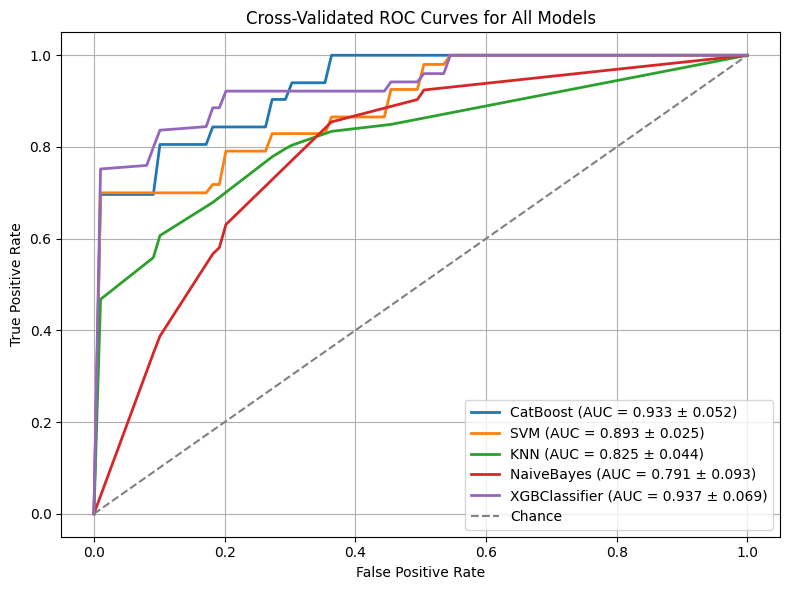

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Load data
data = np.load("train_data.npz")
X = data['X_train']
y = data['y_train']

# Define models
models = {
    "CatBoost": CatBoostClassifier(task_type="GPU", devices="0", verbose=0, random_state=42),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(probability=True, random_state=42))
    ]),
    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ]),
    "NaiveBayes": GaussianNB(),
    "XGBClassifier": XGBClassifier(
        tree_method="gpu_hist",
        predictor="gpu_predictor",
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Plot setup
plt.figure(figsize=(8, 6))

# ROC for each model
for name, model in models.items():
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    for train_idx, test_idx in cv.split(X, y):
        X_train_cv, X_test_cv = X[train_idx], X[test_idx]
        y_train_cv, y_test_cv = y[train_idx], y[test_idx]

        model.fit(X_train_cv, y_train_cv)
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test_cv)[:, 1]
        else:
            df = model.decision_function(X_test_cv)
            y_score = (df - df.min()) / (df.max() - df.min())

        fpr, tpr, _ = roc_curve(y_test_cv, y_score)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    plt.plot(mean_fpr, mean_tpr, label=f"{name} (AUC = {mean_auc:.3f} ± {std_auc:.3f})", lw=2)

# Chance line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')

# Final touches
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cross-Validated ROC Curves for All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig("cv_roc_all_models.png", dpi=300)
plt.show()


In [9]:
# data = np.load('test_data.npz')
# X_test, y_test = data['X_test'], data['y_test']
# data = np.load('train_data.npz')
# X_train, y_train = data['X_train'], data['y_train']## for voting ensembl
from sklearn.ensemble import VotingClassifier
import joblib
import numpy as np
from sklearn.metrics import (
    precision_score, recall_score, confusion_matrix, matthews_corrcoef,
    roc_auc_score, average_precision_score
)

# — assume X_train, y_train, X_test, y_test are already prepared —


# 1) Load your tuned base models
cat = joblib.load("catboost_best_model.pkl")
xgb = joblib.load("xgbclassifier_best_model.pkl")
svm = joblib.load("svm_best_model.pkl")

# 2) Build the soft-voting ensemble
voting = VotingClassifier(
    estimators=[
        ('cat', cat),
        ('xgb', xgb),
        ('svm', svm)
    ],
    voting='soft',          # average predicted probabilities
    weights=[2, 2, 1],      # favor the two tree models
    n_jobs=-1
)

# 3) Fit on your balanced training data
voting.fit(X_train, y_train)

# 4) Predict & evaluate
y_pred  = voting.predict(X_test)
y_proba = voting.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
print("Precision:   ", precision_score(y_test, y_pred))
print("Recall:      ", recall_score(y_test, y_pred))
print("Specificity: ", tn / (tn + fp))
print("MCC:         ", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:     ", roc_auc_score(y_test, y_proba))
print("PR AUC:      ", average_precision_score(y_test, y_proba))

# 5) (Optional) Save your ensemble
joblib.dump(voting, "cat_xgb_svm_voting.pkl")


/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [14:13:16] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [14:13:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/joblib/externals/cloudpickle/cloudpickle.py:1303: UserWarning: [14:13:16] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  return super().dump(obj)


Precision:    0.7857142857142857
Recall:       0.9565217391304348
Specificity:  0.6
MCC:          0.6177498740042754
ROC AUC:      0.9536231884057972
PR AUC:       0.9736627028100855


['cat_xgb_svm_voting.pkl']

In [ ]:
#Library evailuation and screening
import pandas as pd
import numpy as np
import joblib
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.ensemble import VotingClassifier  # if you need to rebuild
from tqdm import tqdm

# 1) Load your trained ensemble
model = joblib.load("cat_xgb_svm_voting.pkl")

# 2) Featurization helper
def smiles_to_fp(smiles_list, radius=2, nbits=2048):
    fps = np.zeros((len(smiles_list), nbits), dtype=np.uint8)
    for i, smi in enumerate(smiles_list):
        m = Chem.MolFromSmiles(smi)
        if m:
            bitvect = AllChem.GetMorganFingerprintAsBitVect(m, radius, nbits)
            arr = np.zeros((nbits,), dtype=int)
            DataStructs.ConvertToNumpyArray(bitvect, arr)
            fps[i, :] = arr
    return fps

# 3) Stream in chunks, predict, and write out
input_csv  = "coconut_csv-06-2025.csv"
output_csv = "library_with_predictions.csv"
chunksize  = 20_000

reader = pd.read_csv(input_csv, chunksize=chunksize)

# Write header once
first = True
for chunk in tqdm(reader, desc="Chunks"):
    # a) Featurize
    smiles = chunk["canonical_smiles"].fillna("").values
    X_chunk = smiles_to_fp(smiles)

    # b) Predict labels & scores
    y_pred  = model.predict(X_chunk)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_chunk)[:, 1]
    else:
        # fallback to decision_function → sigmoid
        dfun   = model.decision_function(X_chunk)
        y_score = 1 / (1 + np.exp(-dfun))

    # c) Append results to chunk frame
    chunk = chunk.assign(
        pred_label = y_pred,
        pred_score = y_score
    )

    # d) Write (append) to disk
    chunk.to_csv(
        output_csv,
        mode='w' if first else 'a',
        header=first,
        index=False
    )
    first = False

print(f"\n✅ Done! Predictions saved to {output_csv}")


Chunks: 0it [00:00, ?it/s][19:18:02] Explicit valence for atom # 4 N, 4, is greater than permitted
[19:18:02] Explicit valence for atom # 6 N, 4, is greater than permitted
[19:18:02] Explicit valence for atom # 6 N, 4, is greater than permitted
[19:18:02] Explicit valence for atom # 2 N, 4, is greater than permitted
[19:18:02] Explicit valence for atom # 11 N, 4, is greater than permitted
[19:18:02] Explicit valence for atom # 3 N, 4, is greater than permitted
[19:18:02] Explicit valence for atom # 9 N, 4, is greater than permitted
[19:18:02] Explicit valence for atom # 3 N, 4, is greater than permitted
[19:18:02] Explicit valence for atom # 7 N, 4, is greater than permitted
[19:18:02] Explicit valence for atom # 1 N, 4, is greater than permitted
[19:18:02] Explicit valence for atom # 1 N, 4, is greater than permitted
[19:18:02] Explicit valence for atom # 5 N, 4, is greater than permitted
[19:18:02] Explicit valence for atom # 20 C, 5, is greater than permitted
[19:18:02] Explicit val


✅ Done! Predictions saved to /media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/FDA_TTBK1predictions.csv


In [ ]:
# For active molecule sorting to othr file 
import pandas as pd

# 1) Load the file you just generated
df = pd.read_csv("library_with_predictions.csv")

# 2) Count how many predicted 0’s vs. 1’s
counts = df["pred_label"].value_counts().sort_index()
print("Label counts:\n", counts)

# 3) (Optional) Also show percentages
percent = df["pred_label"].value_counts(normalize=True).sort_index() * 100
print("\nLabel percentages:\n", percent)

# ─────────────────────────────────────────────────────────────────────────────
# 4) Extract only the predicted actives
actives = df.loc[df["pred_label"] == 1, 
                 ["identifier","name","canonical_smiles", "pred_score"]]

print(f"\nNumber of actives extracted: {len(actives)}")

# 5) Save them to a new CSV
actives.to_csv("library_actives_only.csv", index=False)
print("Saved actives to library_actives_only.csv")


Label counts:
 pred_label
0    1200
1    2565
Name: count, dtype: int64

Label percentages:
 pred_label
0    31.87251
1    68.12749
Name: proportion, dtype: float64


KeyError: "['identifier', 'name', 'canonical_smiles'] not in index"

In [ ]:
import numpy as np
import joblib
from sklearn.metrics import roc_curve

# # 1) load your held-out set
# data = np.load('train_test_data.npz')
# X_test = data['X_test']
# y_test = data['y_test']

# 2) load your fitted model (e.g. your voting ensemble or any single model)
model = joblib.load('cat_xgb_knn_voting.pkl')  # or whichever .pkl you want

# 3) get the positive‐class probabilities
if hasattr(model, "predict_proba"):
    y_probs = model.predict_proba(X_test)[:, 1]
else:
    # for models without predict_proba, use decision_function + sigmoid
    df = model.decision_function(X_test)
    y_probs = 1 / (1 + np.exp(-df))

# 4) compute ROC curve and Youden’s J
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"Youden’s J optimal threshold: {best_threshold:.3f}")
print(f"Sensitivity: {tpr[best_idx]:.3f}, Specificity: {(1-fpr[best_idx]):.3f}")


Youden’s J optimal threshold: 0.263
Sensitivity: 0.478, Specificity: 1.000


/home/umar/.local/lib/python3.10/site-packages/xgboost/core.py:2676: UserWarning: [20:41:03] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
